In [2]:
from Bio import Entrez, SeqIO

Entrez.email = "sundayabdulsalam@gmail.com"

handle = Entrez.efetch(
    db="nucleotide",
    id="MT121215.1",
    rettype="gb",
    retmode="text"
)

record = SeqIO.read(handle, "genbank")
handle.close()

print("ID:", record.id)
print("Description:", record.description)
print("Sequence length:", len(record.seq))
print("Number of features:", len(record.features))

ID: MT121215.1
Description: Severe acute respiratory syndrome coronavirus 2 isolate SARS-CoV-2/human/CHN/SH01/2020, complete genome
Sequence length: 29945
Number of features: 21


In [3]:
covid_dna = record.seq
print(f"The genome of covid_dna contains {len(covid_dna)} nucleotides")

The genome of covid_dna contains 29945 nucleotides


In [4]:
#Molecular weight of the genome
from Bio.SeqUtils import molecular_weight
mw = molecular_weight(covid_dna, seq_type='DNA')
print(f"The molecular weight of the genome is {mw} g/mol")

The molecular weight of the genome is 9254403.9102 g/mol


In [5]:
#GC Content of the genome
from Bio.SeqUtils import gc_fraction
gc_content = gc_fraction(covid_dna)
print(f"The GC content of the genome is {gc_content:.2f}%")

The GC content of the genome is 0.38%


In [6]:
#Distribution of nucleotide 
count_nucleotides = {
    "A": covid_dna.count("A"),  
    "T": covid_dna.count("T"),
    "G": covid_dna.count("G"),
    "C": covid_dna.count("C")
}
print("Nucleotide distribution:")
for nucleotide, count in count_nucleotides.items():
    print(f"{nucleotide}: {count}") 

Nucleotide distribution:
A: 8996
T: 9596
G: 5863
C: 5490


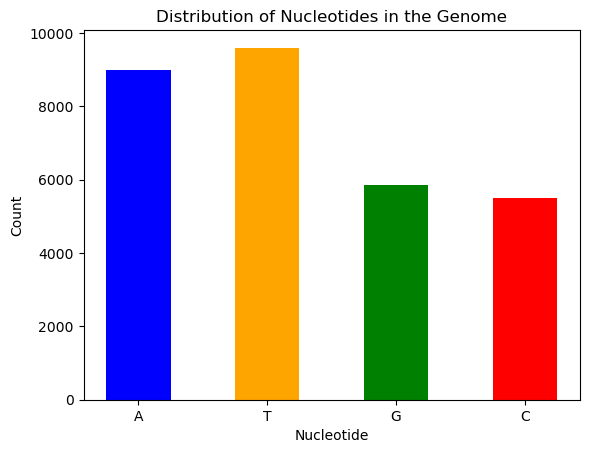

In [7]:
#Graph plot of nucleotide distribution
import matplotlib.pyplot as plt
width =0.5
plt.bar(count_nucleotides.keys(), count_nucleotides.values(), width, color=['blue', 'orange', 'green', 'red'])
plt.xlabel("Nucleotide")
plt.ylabel("Count")
plt.title("Distribution of Nucleotides in the Genome")
plt.show()

In [8]:
#Transcription of the genome
covid_mrna = covid_dna.transcribe()
print(f"The genome of covid_mrna contains {len(covid_mrna)} nucleotides ")

The genome of covid_mrna contains 29945 nucleotides 


In [9]:
#Translation of the genome
protein_sequence = covid_mrna.translate()
print(f"The genome of protein_sequence contains {len(protein_sequence)} amino acids ")  

The genome of protein_sequence contains 9981 amino acids 


c:\Users\HP\anaconda3\Lib\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [10]:
#most common amino acid
from collections import Counter
common_amino_acid = Counter(protein_sequence)
common_amino_acid.most_common(10)



[('L', 886),
 ('S', 809),
 ('*', 774),
 ('T', 678),
 ('C', 635),
 ('F', 594),
 ('R', 558),
 ('V', 548),
 ('Y', 505),
 ('N', 472)]

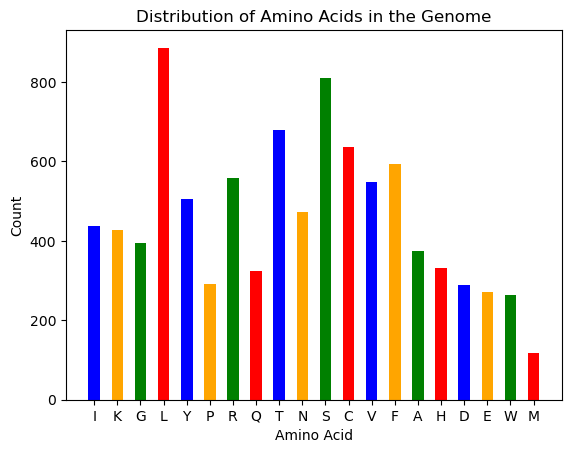

In [11]:
#Plot graph of amino acid distribution
del common_amino_acid['*']

width = 0.5

plt.bar(
    list(common_amino_acid.keys()),
    list(common_amino_acid.values()),
    width,
    color=['blue', 'orange', 'green', 'red']
)

plt.xlabel("Amino Acid")
plt.ylabel("Count")
plt.title("Distribution of Amino Acids in the Genome")

plt.show()

In [12]:
#total amino acid present
print(f"The total number of amino acids in the genome is {sum(common_amino_acid.values())}")

The total number of amino acids in the genome is 9207


In [13]:
#remove stop codons from the protein sequence
protein_sequence_no_stop = protein_sequence.split("*")
protein_sequence_no_stop[:5]

[Seq('IKGLYLPR'),
 Seq('QTNQLSISCRSVL'),
 Seq('TNFKICVAVTRLHA'),
 Seq('CTHAV'),
 Seq('LITNYCR')]

In [14]:
print(f'we have {len(protein_sequence_no_stop)} protein sequences after removing the stop codons')

we have 775 protein sequences after removing the stop codons


In [15]:
# Functional proteins: proteins with at least 20 amino acids

protein_sequence_no_stop = [
    protein
    for protein in protein_sequence_no_stop
    if len(protein) >= 20
]

print(
    f"We have {len(protein_sequence_no_stop)} proteins with length "
    f"greater than or equal to 20 amino acids in the genome after removing stop codons."
)

We have 81 proteins with length greater than or equal to 20 amino acids in the genome after removing stop codons.


In [16]:
#Sort proteins by lenght
top_5_proteins= sorted(protein_sequence_no_stop, key=len)


In [17]:
top_5_proteins[-1]


Seq('CTIVFKRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKTNCCRFQ...VNN')

In [18]:
len(top_5_proteins[-1])

2701

In [19]:
#save to fasta file
with open("protein_seq.fasta", "w") as file:
    file.write(f">covid protein\n{top_5_proteins[-1]}\n")

In [20]:
#blast search
from Bio import SeqIO
protein_seq= SeqIO.read("protein_seq.fasta", "fasta")

In [21]:
protein_seq

SeqRecord(seq=Seq('CTIVFKRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKTNCCRFQ...VNN'), id='covid', name='covid', description='covid protein', dbxrefs=[])

In [22]:
from Bio.Blast import NCBIWWW, NCBIXML
result_handle = NCBIWWW.qblast("blastp", "pdb", protein_seq.seq)

In [23]:
from Bio import SearchIO
blast_qresult = SearchIO.read(result_handle, "blast-xml")
print(blast_qresult[0:10])

Program: blastp (2.17.0+)
  Query: unnamed (2701)
         protein product
 Target: pdb
   Hits: ----  -----  ----------------------------------------------------------
            #  # HSP  ID + description
         ----  -----  ----------------------------------------------------------
            0      1  pdb|9SAP|A  Chain A, RNA-directed RNA polymerase nsp12 ...
            1      1  pdb|7D4F|A  Chain A, RNA-directed RNA polymerase [Sever...
            2      1  pdb|6YYT|A  Chain A, nsp12 [Severe acute respiratory sy...
            3      1  pdb|6XEZ|A  Chain A, RNA-directed RNA polymerase [Sever...
            4      1  pdb|9SAO|A  Chain A, RNA-directed RNA polymerase nsp12 ...
            5      1  pdb|9CGV|A  Chain A, RNA-directed RNA polymerase nsp12 ...
            6      1  pdb|7BW4|A  Chain A, RNA-directed RNA polymerase [Sever...
            7      1  pdb|6XQB|A  Chain A, RNA-directed RNA polymerase [Sever...
            8      1  pdb|7BV1|A  Chain A, RNA-directed RNA pol

In [24]:
for blast_hit in blast_qresult[0:10]:
    print(f"Hit ID: {blast_hit.id}")
    print(f"Hit Description: {blast_hit.description}")
    print(f"Hit E-value: {blast_hit[0].evalue}")
    print(f"Hit Score: {blast_hit[0].bitscore}")
    print(f"Hit Length: {blast_hit.seq_len}")
    print(f"Hit Alignment: {blast_hit[0].aln}")
    print()

Hit ID: pdb|9SAP|A
Hit Description: Chain A, RNA-directed RNA polymerase nsp12 [Severe acute respiratory syndrome coronavirus 2]
Hit E-value: 0.0
Hit Score: 1938.7
Hit Length: 928
Hit Alignment: Alignment with 2 rows and 925 columns
FKRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKT...VLQ unnamed
LNRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKT...VLQ pdb|9SAP|A

Hit ID: pdb|7D4F|A
Hit Description: Chain A, RNA-directed RNA polymerase [Severe acute respiratory syndrome coronavirus 2]
Hit E-value: 0.0
Hit Score: 1938.7
Hit Length: 943
Hit Alignment: Alignment with 2 rows and 926 columns
FKRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKT...LQA unnamed
LNRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKT...LQG pdb|7D4F|A

Hit ID: pdb|6YYT|A
Hit Description: Chain A, nsp12 [Severe acute respiratory syndrome coronavirus 2]
Hit E-value: 0.0
Hit Score: 1938.31
Hit Length: 935
Hit Alignment: Alignment with 2 rows and 925 columns
FKRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKT...VLQ unnamed
LNRVCGVSAARLTPCGTGTSTDVVYRAFDIY

In [25]:
#visualization of cold protein structure
seq_id = "pdb|9SAP|A"


In [26]:
seq_id1 = "pdb|7D4F|A"

In [30]:
id=seq_id.split("|")[1]

In [27]:
id1=seq_id1.split("|")[1]

In [31]:
id

'9SAP'

In [29]:
id1

'7D4F'

In [34]:
#Downloading the Protein Structure
from urllib.request import urlretrieve

url = "https://files.rcsb.org/download/9SAP.pdb"
filename = "9SAP.pdb"

urlretrieve(url, filename)

print(f"{filename} downloaded successfully!")

9SAP.pdb downloaded successfully!


In [32]:
#Downloading the Protein Structure
from urllib.request import urlretrieve

url = "https://files.rcsb.org/download/7D4F.pdb"
filename1 = "7D4F.pdb"

urlretrieve(url, filename1)

print(f"{filename1} downloaded successfully!")

7D4F.pdb downloaded successfully!


In [35]:
filename

'9SAP.pdb'

In [36]:
filename1

'7D4F.pdb'

In [37]:
#reading the PDB file
from Bio.PDB import PDBParser
parser = PDBParser()


In [38]:
# Read the protein structure
structure = parser.get_structure("9SAP", "9SAP.pdb")

c:\Users\HP\anaconda3\Lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 9396.
  warnings.warn(


In [41]:
# Read the protein structure
structure1 = parser.get_structure("7D4F", "7D4F.pdb")

In [40]:
#identify the number of chains in the protein structure
for chain in structure[0]:
    print(f"Chain ID: {chain.id}, Number of residues: {len(chain)}")

Chain ID: B, Number of residues: 114
Chain ID: C, Number of residues: 63
Chain ID: G, Number of residues: 106
Chain ID: A, Number of residues: 902


In [42]:
#identify the number of chains in the protein structure
for chain in structure1[0]:
    print(f"Chain ID: {chain.id}, Number of residues: {len(chain)}")

Chain ID: B, Number of residues: 114
Chain ID: C, Number of residues: 63
Chain ID: G, Number of residues: 106
Chain ID: A, Number of residues: 902


In [43]:
%pip install nglview

Note: you may need to restart the kernel to use updated packages.


In [44]:
import nglview as nv

In [45]:
# Create an interactive 3D view of the protein structure
view = nv.show_biopython(structure, gui=True)


In [47]:
view1 = nv.show_biopython(structure1, gui=True)

In [48]:
# Display the structure
view

NGLWidget()

In [49]:
view1

NGLWidget()